Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

reading data from csv file using pandas

In [2]:
df=pd.read_csv("insurance_dataset.csv")

understanding data

In [4]:
print(df.shape)
print(df.head())
print(df.dtypes)
print(df.isnull().sum())
print(df.describe())

(1338, 7)
   age     sex     bmi  children smoker     region      charges
0   19    male  27.900         0    yes  northeast  16884.92400
1   18  female  33.770         1     no  northwest   1725.55230
2   28  female  33.000         3     no  northwest   4449.46200
3   33  female  22.705         0     no  southeast  21984.47061
4   32  female  28.880         0     no  southeast   3866.85520
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000  

selecting variables for input and output

In [5]:
X = df[['bmi']]   # bmi as independent variable
y = df['charges']       # chares as the dependant variable

visuallizing data for better understanding

Text(0.5, 1.0, 'BMI vs Insurance Charges')

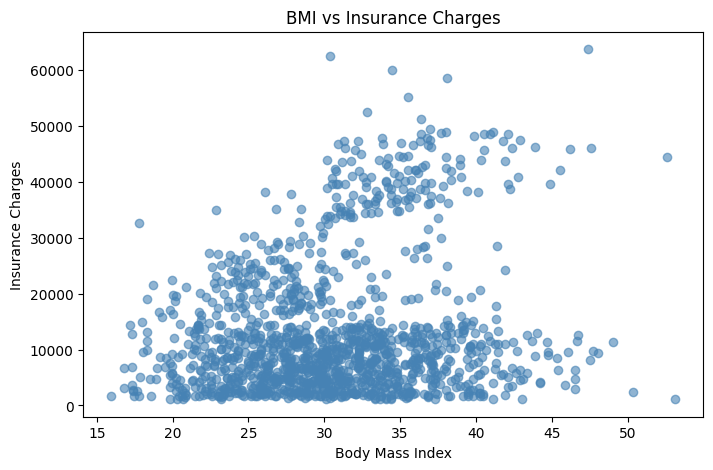

In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='steelblue', alpha=0.6)
plt.xlabel('Body Mass Index')
plt.ylabel('Insurance Charges')
plt.title('BMI vs Insurance Charges')

Splitting data for testing and training

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")


Training samples : 1070
Testing  samples : 268


Training the model using Linear Regression

In [12]:
model = LinearRegression()
model.fit(X_train, y_train)   #here model learns data like for what value x
                               # what is the value of y

slope     = model.coef_[0]      # m — how much charges rises per extra bmi
intercept = model.intercept_    # b — base charges at 0 bmi

print(f"\n--- Model Coefficients ---")
print(f"Slope (m)     : {slope:.4f} ")
print(f"Intercept (b) : {intercept:.2f}")
print(f"Formula       : charages = {slope:.2f} × bmi + {intercept:.2f}")


--- Model Coefficients ---
Slope (m)     : 392.4365 
Intercept (b) : 1353.07
Formula       : charages = 392.44 × bmi + 1353.07


Testing the model

In [13]:
y_pred = model.predict(X_test)   #we ask the model to predict insurance charges
                                  # for some X_value(bmi)

mae = mean_absolute_error(y_test, y_pred) #compares the result with actuall value

r2  = r2_score(y_test, y_pred)  #variation in charges

print(f"\n--- Evaluation Metrics ---")
print(f"MAE (Mean Absolute Error) : PKR {mae:.2f}")
print(f"  → On average, predictions are off by: PKR {mae:.2f}")
print(f"R² Score                  : {r2:.4f}")
print(f"  → The model explains {r2*100:.1f}% of the variation in insurance charges")


--- Evaluation Metrics ---
MAE (Mean Absolute Error) : PKR 9784.65
  → On average, predictions are off by: PKR 9784.65
R² Score                  : 0.0397
  → The model explains 4.0% of the variation in insurance charges


plotting the regression line

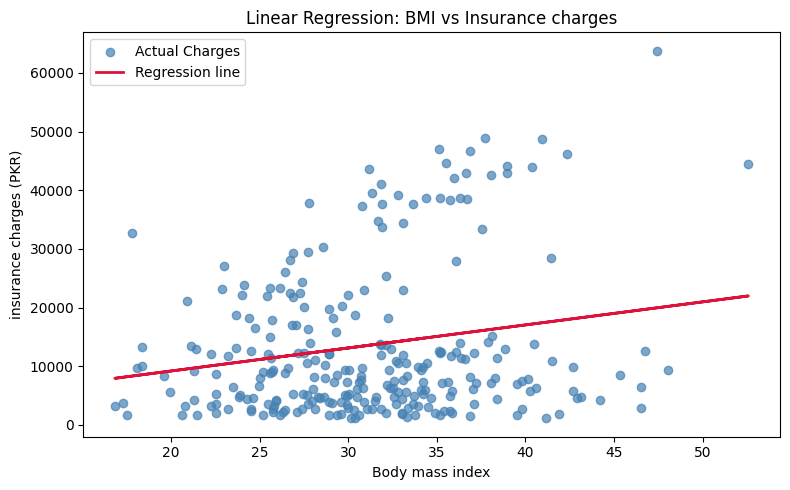

In [14]:
plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, color='steelblue', alpha=0.7,
            label='Actual Charges')
plt.plot(X_test, y_pred, color='crimson', linewidth=2,
         label='Regression line')
plt.xlabel('Body mass index')
plt.ylabel('insurance charges (PKR)')
plt.title('Linear Regression: BMI vs Insurance charges')
plt.legend()
plt.tight_layout()



Visualize Model Performance

If the model were perfect, every dot would sit on the red line.

Points far from the line = bigger prediction errors.


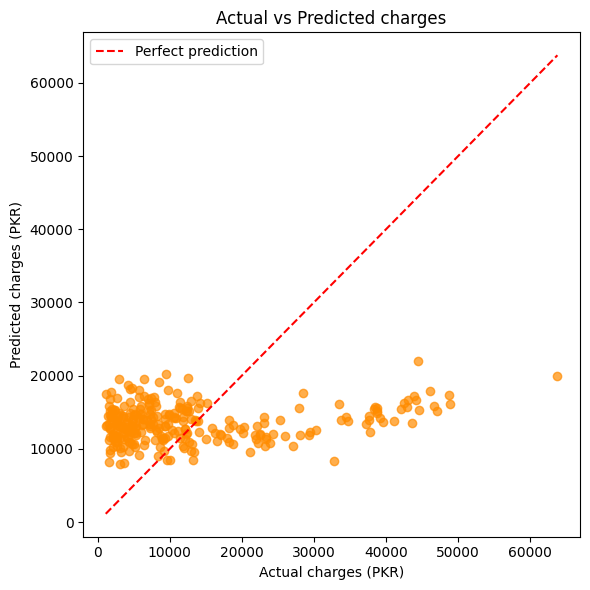

In [16]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, color='darkorange', alpha=0.7)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5,
         label='Perfect prediction')
plt.xlabel('Actual charges (PKR)')
plt.ylabel('Predicted charges (PKR)')
plt.title('Actual vs Predicted charges')
plt.legend()
plt.tight_layout()


Making new prediction

In [19]:
new_dataset = pd.DataFrame({'bmi': [33.05, 19.2, 36.89, 42.3, 50.0]})
predicted_charges = model.predict(new_dataset)

print("\n--- Predictions on New Dataset ---")
for bmi, charges in zip(new_dataset['bmi'], predicted_charges):
    print(f"  {bmi} bmi  →  PKR {charges:,.0f} charges")


--- Predictions on New Dataset ---
  33.05 bmi  →  PKR 14,323 charges
  19.2 bmi  →  PKR 8,888 charges
  36.89 bmi  →  PKR 15,830 charges
  42.3 bmi  →  PKR 17,953 charges
  50.0 bmi  →  PKR 20,975 charges
